# Example: Noisy Data

- Author: Dr. Daning Huang
- Date: 05/08/2026

## Introduction

Most of the other examples assume clean data.  But noise appears practically in all real datasets.  In this example, we show a workflow in `DyMAD` to deal with noisy data.  It merely adds a denoising step in data preprocessing, and then a reasonably good model can still be learned from data.

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import torch

WORK_DIR = Path.cwd()

## Data Generation

We use the same synthetic LTI system like some other examples.  `DyMAD` provides a handy tool to sample noisy data for testing purposes.  The training dataset is generated from clean trajectories, then observation noise is added to the data set.

The entries in `noise_options` should be self-explanatory.  In this example, we just consider the uniform distribution.

In [2]:
from dymad.io import DataInterface, load_model
from dymad.models import LTI
from dymad.training import StackedTrainer
from dymad.utils import TrajectorySampler, plot_summary, plot_trajectory

B = 128
N = 501
t_grid = np.linspace(0, 5, N)

A = np.array([[0.0, 1.0], [-1.0, -0.1]])

def f(t, x, u):
    return (x @ A.T) + u

def g(t, x, u):
    return x

config_chr = {
    "control": {
        "kind": "chirp",
        "params": {
            "t1": 4.0,
            "freq_range": (0.5, 2.0),
            "amp_range": (0.5, 1.0),
            "phase_range": (0.0, 360.0),
        },
    }
}

config_gau = {
    "control": {
        "kind": "gaussian",
        "params": {"mean": 0.5, "std": 1.0, "t1": 4.0, "dt": 0.2, "mode": "zoh"},
    }
}

noise_options = [
    {
        "kind": "gaussian",
        "params": {"mean": 0.0, "std": 0.1},
    },
    {
        "kind": "laplace",
        "params": {"loc": [0.0, 0.0], "scale": [0.1, 0.1]},
    },
    {
        "kind": "student_t",
        "params": {"df": [5.0, 5.0], "loc": [0.0, 0.0], "scale": [0.1, 0.1]},
    },
    {
        "kind": "uniform",
        "params": {"bounds": [[-0.1, 0.1], [-0.1, 0.1]]},
    },
]

noise_kind = 3
config_noise = noise_options[noise_kind]
DATA_PATH = WORK_DIR / "data/lti_denoise.npz"

In [3]:
sampler = TrajectorySampler(
    f,
    g,
    config="noise_data.yaml",
    config_mod={**config_chr, "noise": config_noise},
)
ts_train, x_train_truth, u_train, x_train_noisy = sampler.sample(t_grid, batch=B)
np.savez_compressed(DATA_PATH, t=ts_train, x=x_train_noisy, u=u_train)

The saved file contains the noisy observations because that is what the denoise training configs expect. We keep the clean trajectories returned by the sampler in memory so that we can measure how well each denoiser recovers the underlying signal.


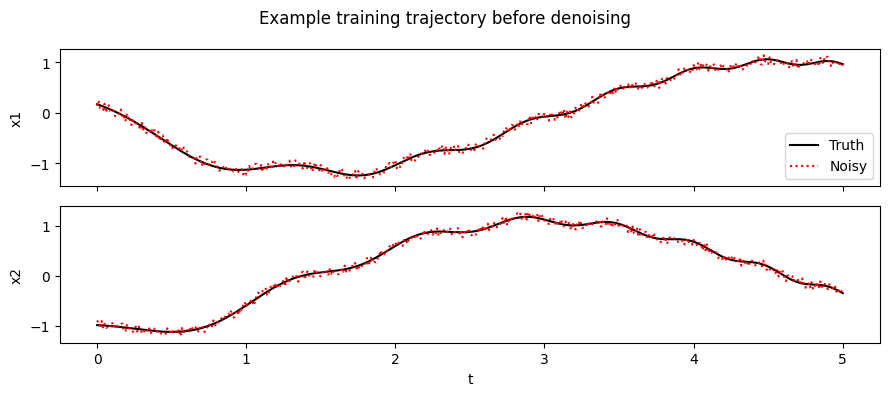

In [4]:
fig, ax = plt.subplots(nrows=2, sharex=True, figsize=(9, 4))
for i in range(2):
    ax[i].plot(ts_train[0], x_train_truth[0, :, i], "k-", label="Truth")
    ax[i].plot(ts_train[0], x_train_noisy[0, :, i], "r:", label="Noisy")
    ax[i].set_ylabel(f"x{i + 1}")
ax[-1].set_xlabel("t")
ax[0].legend()
fig.suptitle("Example training trajectory before denoising")
fig.tight_layout()

## Denoising Algorithms

In this example we show:

- **Savitzky-Golay filtering** smooths a signal by sliding a small polynomial fit across the data and evaluating the fitted polynomial at the center of each window. In plain language, it removes noise while trying to preserve local shape, such as peaks and curvature.
- **Kernel smoothing** follows the idea of kernel regression to fit a smooth curve approximating the signal, thereby achieving smoothing.  Specifically, we consider two kernels below: Gaussian kernel and a compactly-supported polynomial kernel.

Below, we use `DataInterface`, so as to isolate the pre-processing of the dataset.  Here, the smoothing is used as a data transform step.

In [5]:
preprocess_cases = [
    (
        "Savitzky-Golay",
        {
            "type": "denoise",
            "method": "savgol",
            "window_length": 15,
            "polyorder": 5,
        },
    ),
    (
        "Gaussian kernel",
        {
            "type": "denoise",
            "method": "kernel_smoothing",
            "kernel": "gaussian",
            "anchor_count": 64,
            "bandwidth_multiplier": 2.0,
        },
    ),
    (
        "Compact polynomial kernel",
        {
            "type": "denoise",
            "method": "kernel_smoothing",
            "kernel": "compact_polynomial",
            "anchor_count": 64,
            "bandwidth_multiplier": 2.0,
            "degree": 4.0,
        },
    ),
]

def apply_preprocess(config, X):
    interface = DataInterface(
        config_path="noise_wf.yaml",
        config_mod={"transform_x": [config]},
    )
    return interface.encode(X)

def rmse(a, b):
    a, b = np.asarray(a), np.asarray(b)
    return float(np.sqrt(np.mean((a - b) ** 2)))

denoised_train = {name: apply_preprocess(config, x_train_noisy) for name, config in preprocess_cases}
signal_rmse = {"Noisy observation": rmse(x_train_noisy, x_train_truth)}
signal_rmse.update({name: rmse(value, x_train_truth) for name, value in denoised_train.items()})

for name, value in signal_rmse.items():
    print(f"{name:28s} RMSE = {value:.6f}")

Noisy observation            RMSE = 0.057838
Savitzky-Golay               RMSE = 0.028660
Gaussian kernel              RMSE = 0.020719
Compact polynomial kernel    RMSE = 0.021121


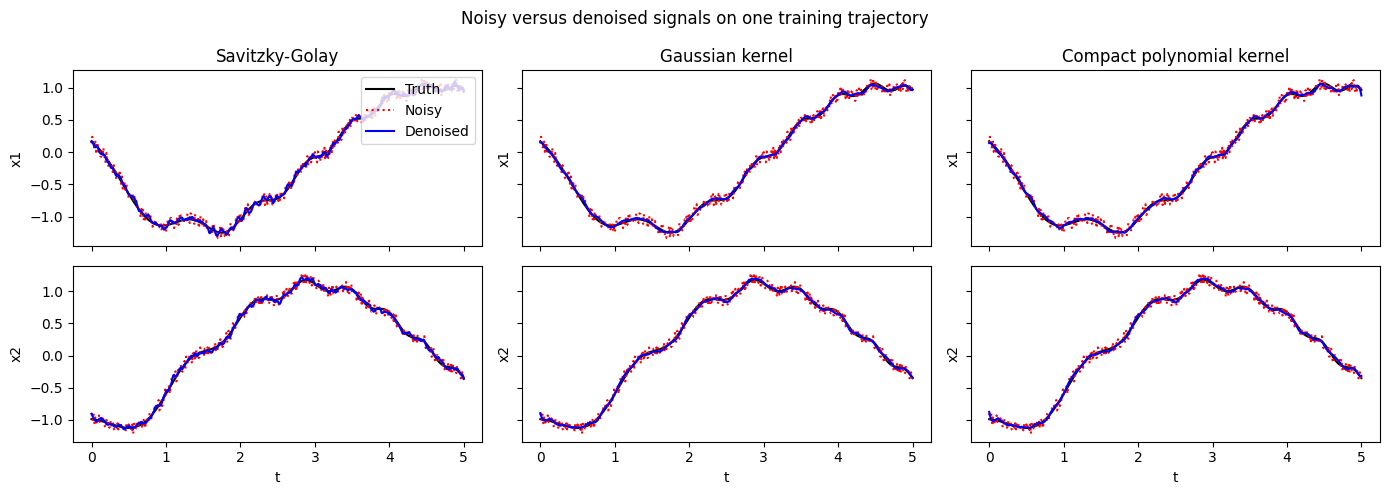

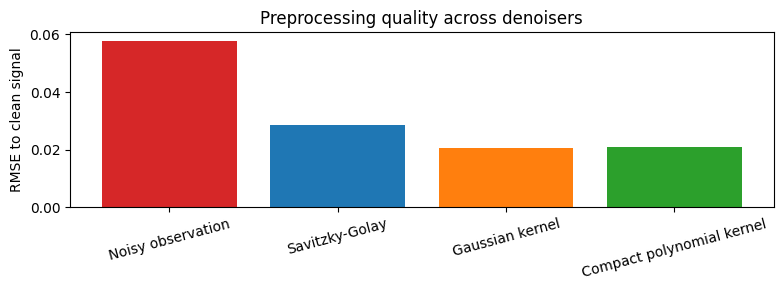

In [6]:
fig, ax = plt.subplots(
    nrows=2,
    ncols=len(preprocess_cases),
    sharex=True,
    sharey="row",
    figsize=(14, 5),
)

for j, (name, _) in enumerate(preprocess_cases):
    Z = denoised_train[name]
    for i in range(2):
        ax[i, j].plot(ts_train[0], x_train_truth[0, :, i], "k-", label="Truth")
        ax[i, j].plot(ts_train[0], x_train_noisy[0, :, i], "r:", label="Noisy")
        ax[i, j].plot(ts_train[0], Z[0, :, i], "b-", label="Denoised")
        ax[i, j].set_ylabel(f"x{i + 1}")
    ax[0, j].set_title(name)

for j in range(len(preprocess_cases)):
    ax[-1, j].set_xlabel("t")

ax[0, 0].legend(loc="upper right")
fig.suptitle("Noisy versus denoised signals on one training trajectory")
fig.tight_layout()

fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(
    signal_rmse.keys(),
    signal_rmse.values(),
    color=["tab:red", "tab:blue", "tab:orange", "tab:green"],
)
ax.set_ylabel("RMSE to clean signal")
ax.set_title("Preprocessing quality across denoisers")
ax.tick_params(axis="x", rotation=15)
fig.tight_layout()

## Model Training

In modeling training, the data smoothing is specified through one of the phases.  See one example below:

- Note that the `optimizer` phase is what we usually see in `DyMAD` training configs.
- Here just one more `data` phase is added before the usual `optimizer` phase.
- During training, the trainer will execute the `data` phase and pass the denoised data to the `optimizer` phase.

In [ ]:
"""
phases:
  - type: 'data'
    name: 'smooth_observations'
    operation: 'smooth'
    method: 'savgol'
    splits: ['train', 'valid']
    window_length: 7
    polyorder: 3

  - type: 'optimizer'
    name: 'weak_fit'
    trainer: 'Weak'
    n_epochs: 500
    save_interval: 10
    load_checkpoint: false
    learning_rate: 5e-3
    weak_form_params:
      N: 13
      dN: 2
      ordpol: 2
      ordint: 2
"""

A side note: It may appear natural to directly add smoothing to data transform, so that only an `optimizer` phase is needed; this is certainly doable.  However, there are model-based smoothing algorithms and the training phase is where a smoothing algorithm can access the model.  Hence, for the more general case, the `data` phase mechanism is created to allow smoothing during training.

In [7]:
training_cases = [
    {
        "label": "Savitzky-Golay + weak form",
        "config": "noise_wf.yaml",
        "checkpoint": "lti_denoise_wf.pt",
        "summary": "lti_denoise_wf",
    },
    {
        "label": "Compact polynomial kernel + weak form",
        "config": "noise_cpp.yaml",
        "checkpoint": "lti_denoise_cpp.pt",
        "summary": "lti_denoise_cpp",
    },
]

for case in training_cases:
    trainer = StackedTrainer(case["config"], LTI)
    trainer.train()

After training, the saved summaries can be plotted in the same way as the script workflow. This is a convenient check that both denoisers converge before we compare prediction accuracy on a new trajectory.


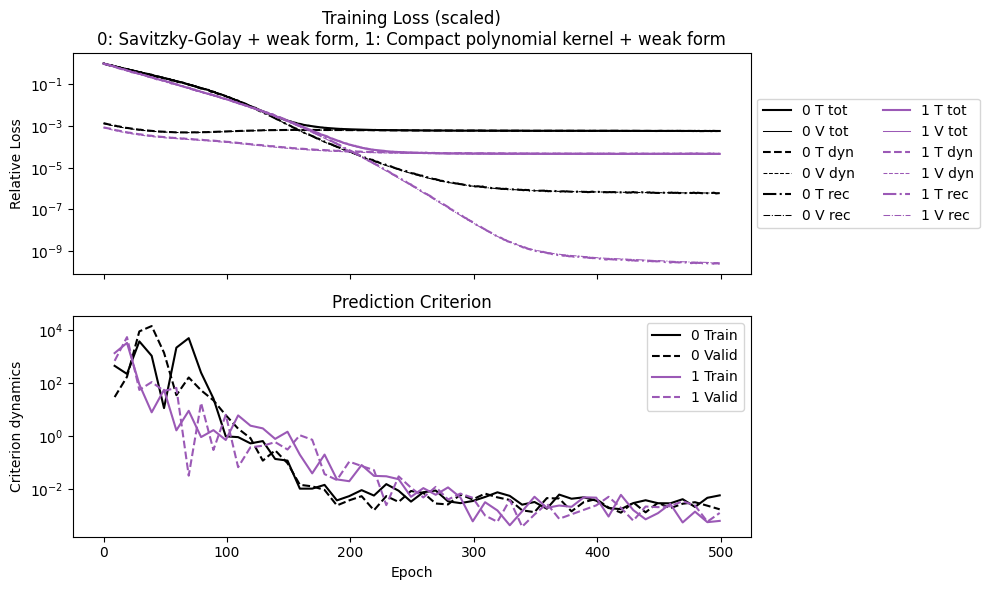

In [8]:
plot_summary(
    [case["summary"] for case in training_cases],
    labels=[case["label"] for case in training_cases],
    ifclose=False,
);

## Model Prediction

We now generate a test trajectory with a different control input distribution, and compare how the two trained denoise pipelines predict the clean dynamics from noisy observations.  Both models perform reasonably well.

In [9]:
sampler = TrajectorySampler(
    f,
    g,
    config="noise_data.yaml",
    config_mod={**config_gau, "noise": config_noise},
)

ts_test, x_test_truth, u_test, x_test_noisy = sampler.sample(t_grid, batch=1)
t_test = ts_test[0]
x_truth = x_test_truth[0]
u_test = u_test[0]
y_noisy = x_test_noisy[0]

prediction_series = [x_truth, y_noisy]
prediction_labels = ["Truth", "Noisy observation"]
prediction_rmse = {"Noisy observation": rmse(y_noisy, x_truth)}

for case in training_cases:
    _, predict = load_model(LTI, case["checkpoint"])
    with torch.no_grad():
        pred = np.asarray(predict(y_noisy, t_test, u=u_test))
    prediction_series.append(pred)
    prediction_labels.append(case["label"])
    prediction_rmse[case["label"]] = rmse(pred, x_truth)

for name, value in prediction_rmse.items():
    print(f"{name:36s} RMSE = {value:.6f}")

Noisy observation                    RMSE = 0.057959
Savitzky-Golay + weak form           RMSE = 0.060616
Compact polynomial kernel + weak form RMSE = 0.111875


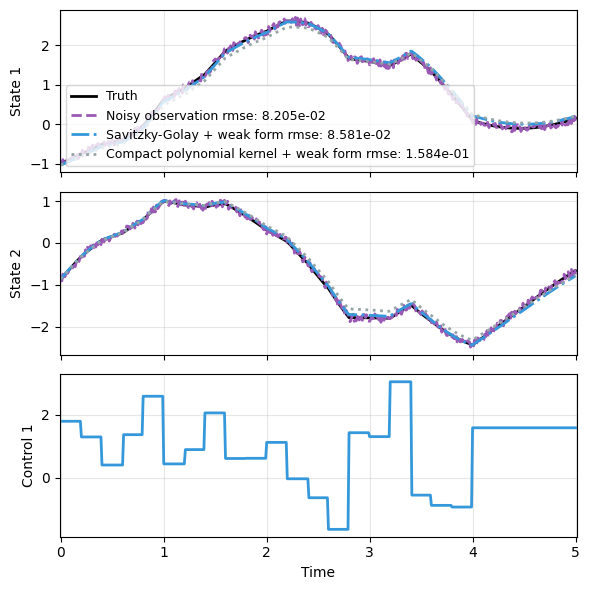

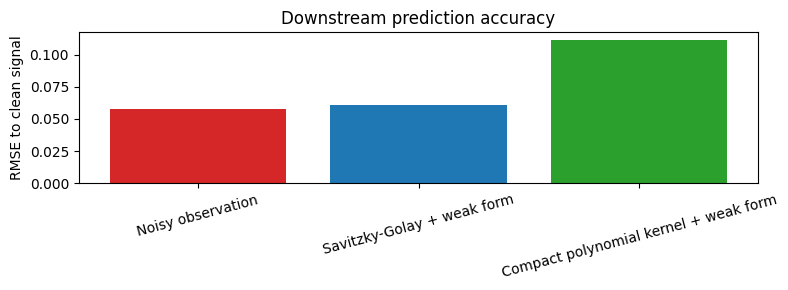

In [10]:
plot_trajectory(
    np.array(prediction_series),
    t_test,
    "lti_denoise_prediction",
    us=u_test,
    labels=prediction_labels,
    ifclose=False,
)

fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(
    prediction_rmse.keys(),
    prediction_rmse.values(),
    color=["tab:red", "tab:blue", "tab:green"],
)
ax.set_ylabel("RMSE to clean signal")
ax.set_title("Downstream prediction accuracy")
ax.tick_params(axis="x", rotation=15)
fig.tight_layout()